In [1]:
# !pip install aeon

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Recurrent Neural Networks

In [3]:
from aeon.datasets import load_classification

### Dataset

**ECG200**

This dataset was formatted by R. Olszewski as part of his thesis "Generalized feature extraction for structural pattern recognition in time-series data" at Carnegie Mellon University, 2001. Each series traces the electrical activity recorded during one heartbeat. The two classes are a normal heartbeat and a Myocardial Infarction.

In [4]:
# Import the dataset
X_train, y_train = load_classification("ECG200", split="train")
X_test, y_test = load_classification("ECG200", split="test")
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100, 1, 96), (100,), (100, 1, 96), (100,))

In [5]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
le.classes_

array(['-1', '1'], dtype='<U2')

In [6]:
LABELS = ["infarction", "normal"]

In [7]:
y_train

array([0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1])

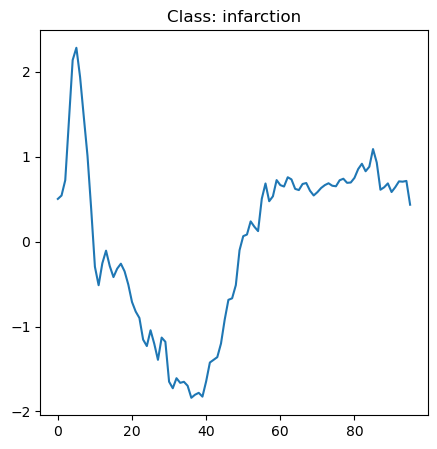

In [8]:
i = 0
plt.figure(figsize=(5, 5))
plt.plot(X_train[i].ravel())
plt.title('Class: {}'.format(LABELS[y_train[i]]))
plt.show()

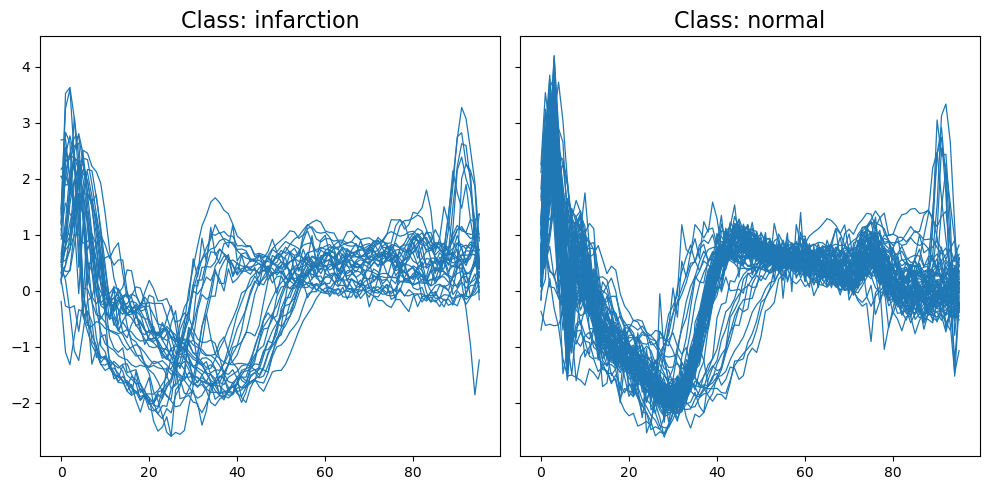

In [9]:
# Dataset visualization
fig, axs = plt.subplots(1, len(le.classes_), figsize=(10, 5), sharey=True)
for i in range(len(le.classes_)):
    for x in X_train[y_train == i]:
        axs[i].plot(x.ravel(), color='C0', linewidth=0.9)
        axs[i].set_title('Class: {}'.format(LABELS[i]), fontsize=16)

plt.tight_layout()
plt.show()

### Vanilla RNN

In [10]:
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring
from skorch.dataset import ValidSplit
from sklearn.metrics import accuracy_score

In [11]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
# build a vanilla RNN with a classification head

class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.swapaxes(x, 1, 2)  # swap the last two dimensions to match RNN input shape
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # take the last output of the sequence
        out = self.fc(out)
        return out

In [13]:
net = NeuralNetClassifier(
    VanillaRNN,
    module__input_size=X_train.shape[1],
    module__hidden_size=32,
    module__output_size=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    max_epochs=200,
    lr=0.01,
    batch_size=32,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=5, stratified=True)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.VanillaRNN'>,
  module__hidden_size=32,
  module__input_size=1,
  module__output_size=2,
)

In [14]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss     dur
-------  -----------  ------------  -----------  ------------  ------
      1       0.2625        0.7152       0.3500        0.7090  0.4373
      2       0.2250        0.7076       0.2500        0.7031  0.1464
      3       0.2375        0.7006       0.3000        0.6977  0.1436
      4       0.5250        0.6939       0.6000        0.6925  0.1417
      5       0.7000        0.6877       0.6500        0.6877  0.1530
      6       0.7000        0.6818       0.6500        0.6832  0.1623
      7       0.7000        0.6762       0.6500        0.6789  0.1483
      8       0.7000        0.6709       0.6500        0.6748  0.1419
      9       0.7000        0.6659       0.6500        0.6710  0.1560
     10       0.7000        0.6611       0.6500        0.6673  0.1660
     11       0.7000        0.6565       0.6500        0.6638  0.1452
     12       0.7000        0.6522       0.6500        0.6605  0.1434
     13       0.7000

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=VanillaRNN(
    (rnn): RNN(1, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=2, bias=True)
  ),
)

In [15]:
y_pred = net.predict(X_test)
accuracy_score(y_test, y_pred)

0.69

In [16]:
net.criterion, net.optimizer

(torch.nn.modules.loss.CrossEntropyLoss, torch.optim.sgd.SGD)

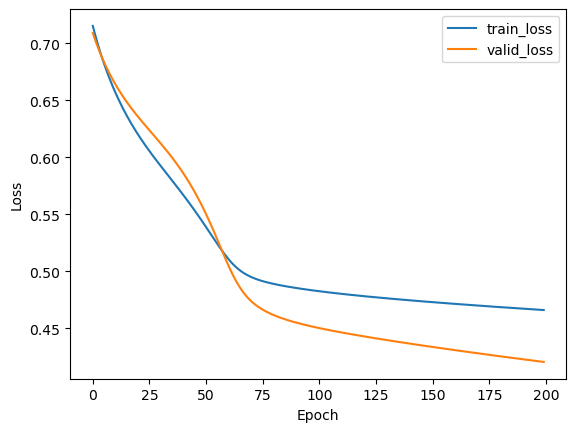

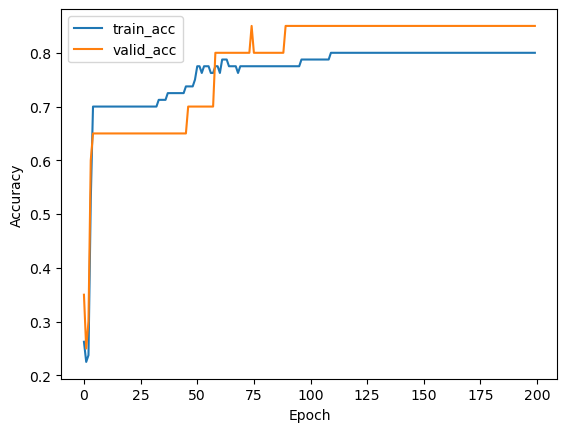

In [17]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### LSTM

In [18]:
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [19]:
# build a vanilla RNN with a classification head

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.swapaxes(x, 1, 2)  # swap the last two dimensions to match RNN input shape
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # take the last output of the sequence
        out = self.fc(out)
        return out

In [20]:
net = NeuralNetClassifier(
    LSTM,
    module__input_size=X_train.shape[1],
    module__hidden_size=32,
    module__output_size=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=500,
    batch_size=32,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=5, stratified=True)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.LSTM'>,
  module__hidden_size=32,
  module__input_size=1,
  module__output_size=2,
)

In [21]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.7000        0.6550       0.6500        0.6367     +  0.2448
      2       0.7000        0.6079       0.6500        0.5962        0.0470
      3       0.7000        0.5641       0.6500        0.5359        0.0470
      4       0.7750        0.5256       0.8000        0.5036     +  0.0470
      5       0.7750        0.5142       0.8500        0.4533     +  0.0483
      6       0.7750        0.5023       0.8000        0.4596        0.0472
      7       0.8000        0.4865       0.7500        0.4728        0.0518
      8       0.8000        0.4813       0.7500        0.4742        0.0492
      9       0.8125        0.4780       0.8000        0.4685        0.0483
     10       0.8000        0.4777       0.8000        0.4599        0.0537
     11       0.8000        0.4767       0.8000        0.4496        0.0553
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTM(
    (rnn): LSTM(1, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=2, bias=True)
  ),
)

In [22]:
y_pred = net.predict(X_test)
accuracy_score(y_test, y_pred)

0.69

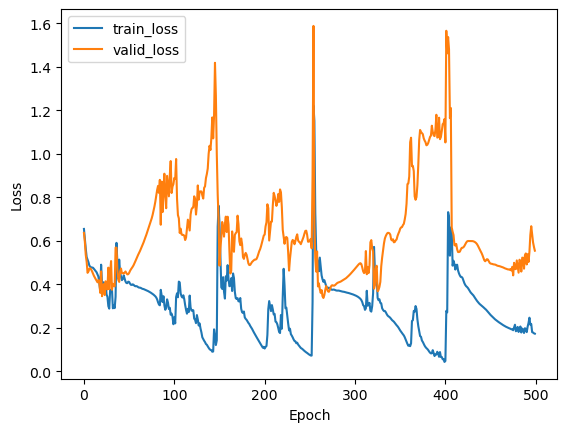

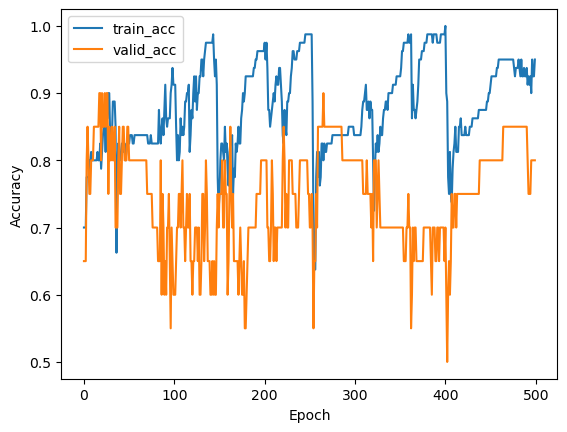

In [23]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#### Trying to fix the unstable training

In [24]:
net = NeuralNetClassifier(
    LSTM,
    module__input_size=X_train.shape[1],
    module__hidden_size=32,
    module__output_size=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=100,
    batch_size=32,
    lr=1e-3,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        ),
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=0.2, stratified=True)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.LSTM'>,
  module__hidden_size=32,
  module__input_size=1,
  module__output_size=2,
)

In [25]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.7000        0.6857       0.7000        0.6801     +  0.0453
      2       0.6875        0.6786       0.7000        0.6736        0.0432
      3       0.6875        0.6718       0.7000        0.6673        0.0432
      4       0.6875        0.6650       0.7000        0.6611        0.0431
      5       0.6875        0.6582       0.7000        0.6547        0.0454
      6       0.6875        0.6510       0.7000        0.6480        0.0476
      7       0.6875        0.6435       0.7000        0.6410        0.0486
      8       0.6875        0.6352       0.7000        0.6334        0.0481
      9       0.6875        0.6259       0.7000        0.6250        0.0476
     10       0.6875        0.6152       0.7000        0.6156        0.0472
     11       0.6875        0.6030       0.7000        0.6053        0.0506
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTM(
    (rnn): LSTM(1, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=2, bias=True)
  ),
)

In [26]:
y_pred = net.predict(X_test)
accuracy_score(y_test, y_pred)

0.77

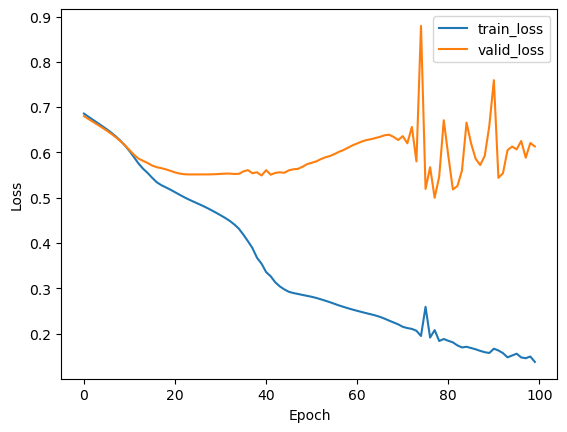

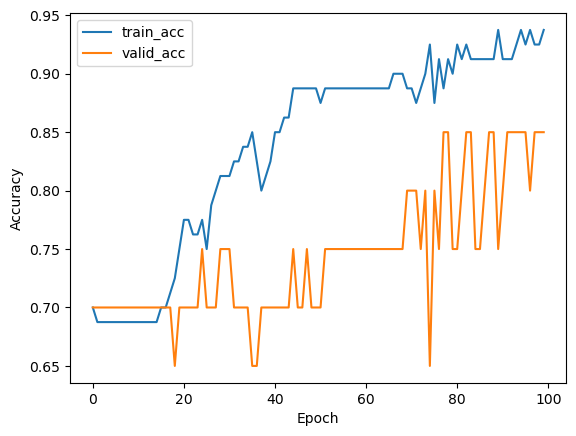

In [27]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#### Bidirectional

In [28]:
# build a vanilla RNN with a classification head

class LSTM2(nn.Module):
    def __init__(
            self, 
            input_size, 
            hidden_size, 
            output_size,
            bidirectional=False,
            num_layers=1,
            ):
        super(LSTM2, self).__init__()
        self.rnn = nn.LSTM(
            input_size, 
            hidden_size, 
            batch_first=True, 
            bidirectional=bidirectional,
            num_layers=num_layers
            )
        self.fc = nn.Linear(
            hidden_size if not bidirectional else hidden_size * 2, 
            output_size
            )

    def forward(self, x):
        x = torch.swapaxes(x, 1, 2)  # swap the last two dimensions to match RNN input shape
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # take the last output of the sequence
        out = self.fc(out)
        return out

In [29]:
net = NeuralNetClassifier(
    LSTM2,
    module__input_size=X_train.shape[1],
    module__hidden_size=32,
    module__output_size=len(le.classes_),
    module__bidirectional=True,
    

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=100,
    batch_size=100,
    lr=1e-4,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        ),
    ],
    device=DEVICE,

    train_split=ValidSplit(cv=0.2, stratified=True)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.LSTM2'>,
  module__bidirectional=True,
  module__hidden_size=32,
  module__input_size=1,
  module__output_size=2,
)

In [30]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.3000        0.7084       0.3000        0.7098     +  0.7769
      2       0.3000        0.7080       0.3000        0.7094        0.0346
      3       0.3000        0.7077       0.3000        0.7091        0.0233
      4       0.3000        0.7074       0.3000        0.7087        0.0247
      5       0.3000        0.7071       0.3000        0.7084        0.0299
      6       0.2875        0.7068       0.3000        0.7080        0.0337
      7       0.2875        0.7064       0.3000        0.7077        0.0250
      8       0.2875        0.7061       0.3000        0.7074        0.0245
      9       0.2875        0.7058       0.3000        0.7070        0.0246
     10       0.2875        0.7055       0.3000        0.7067        0.0252
     11       0.2750        0.7052       0.3000        0.7063        0.0277
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=LSTM2(
    (rnn): LSTM(1, 32, batch_first=True, bidirectional=True)
    (fc): Linear(in_features=64, out_features=2, bias=True)
  ),
)

In [31]:
y_pred = net.predict(X_test)
accuracy_score(y_test, y_pred)

0.63

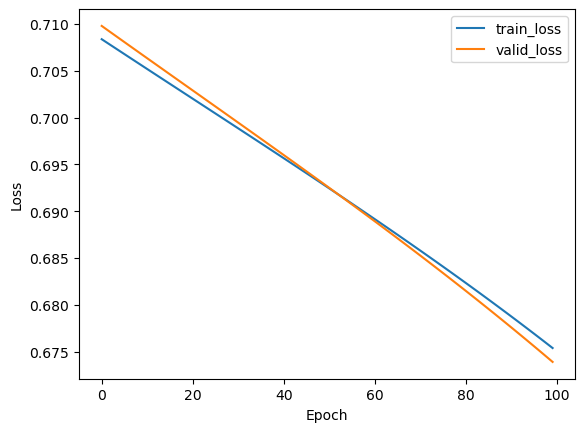

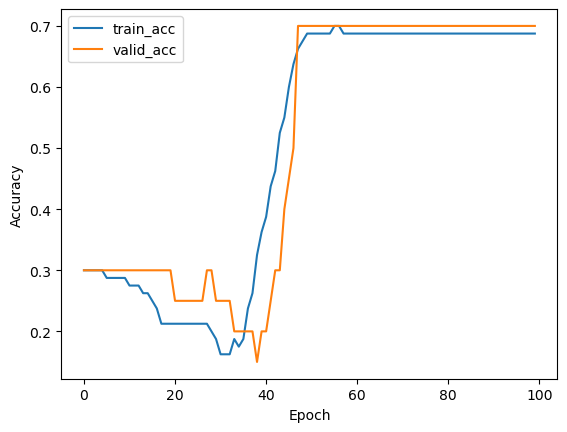

In [32]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### GRU

In [33]:
from skorch.callbacks import Callback
import torch

class GradientClipping(Callback):
    def __init__(self, max_norm=1.0, norm_type=2):
        self.max_norm = max_norm
        self.norm_type = norm_type

    def on_grad_computed(self, net, named_parameters, **kwargs):
        params = [p for _, p in named_parameters if p.grad is not None]
        torch.nn.utils.clip_grad_norm_(
            params,
            max_norm=self.max_norm,
            norm_type=self.norm_type,
        )

In [34]:
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU, self).__init__()
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.swapaxes(x, 1, 2) 
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [35]:
net = NeuralNetClassifier(
    GRU,
    module__input_size=X_train.shape[1],
    module__hidden_size=64,
    module__output_size=len(le.classes_),

    criterion=nn.CrossEntropyLoss,
    optimizer=torch.optim.Adam,
    max_epochs=100,
    batch_size=32,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        ),
        GradientClipping(max_norm=1.0)
    ],
    device="cpu",  # "mps" is known to cause issues with GRUs

    train_split=ValidSplit(cv=0.2, stratified=True)
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.GRU'>,
  module__hidden_size=64,
  module__input_size=1,
  module__output_size=2,
)

In [36]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss    cp     dur
-------  -----------  ------------  -----------  ------------  ----  ------
      1       0.6750        0.7053       0.7000        0.5639     +  1.3439
      2       0.7000        0.5865       0.9000        0.5094     +  0.2875
      3       0.7500        0.5632       0.9500        0.4361     +  0.4382
      4       0.7875        0.5380       0.9500        0.3573        0.4425
      5       0.7625        0.5289       0.9500        0.3439        0.3049
      6       0.7500        0.5090       0.9500        0.3540        0.2860
      7       0.7750        0.5005       0.9500        0.3585        0.2644
      8       0.7875        0.4935       0.9000        0.3482        0.2384
      9       0.7875        0.4831       0.9000        0.3412        0.2543
     10       0.8125        0.4765       0.8500        0.3430        0.2793
     11       0.8125        0.4726       0.8500        0.3421        0.2071
     12     

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=GRU(
    (rnn): GRU(1, 64, batch_first=True)
    (fc): Linear(in_features=64, out_features=2, bias=True)
  ),
)

In [37]:
y_pred = net.predict(X_test)
accuracy_score(y_test, y_pred)

0.66

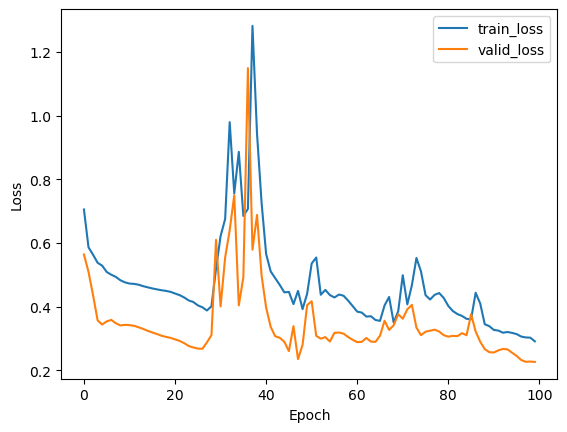

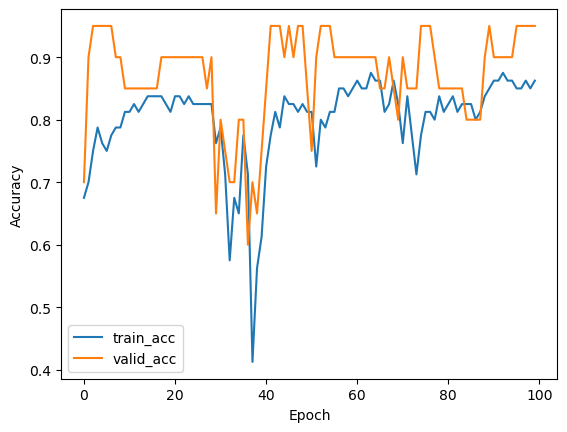

In [38]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Exercise 

Solve the classfication task and find the best model you can.

**Atrial Fibrillation**

This is a physionet dataset of two-channel ECG recordings has been created from data used in the Computers in Cardiology Challenge 2004, an open competition with the goal of developing automated methods for predicting spontaneous termination of atrial fibrillation (AF).

The raw instances were 5 second segments of atrial fibrillation, containing two ECG signals, each sampled at 128 samples per second. The class labels are: n, s and t.

- class n is described as a non termination atrial fibrillation(that is, it did not terminate for at least one hour after the original recording of the data).
- class s is described as an atrial fibrillation that self terminates at least one minute after the recording process.
- class t is described as terminating immediately, that is within one second of the recording ending.
PhysioNet Reference:

In [39]:
# Import the dataset
X_train, y_train = load_classification("AtrialFibrillation", split="train")
X_test, y_test = load_classification("AtrialFibrillation", split="test")
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((15, 2, 640), (15,), (15, 2, 640), (15,))

In [40]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
LABELS = le.classes_
le.classes_

array(['n', 's', 't'], dtype='<U1')

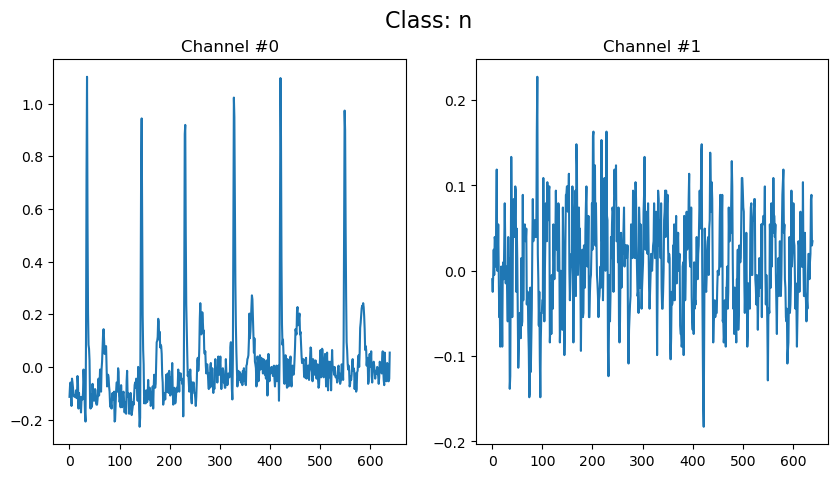

In [41]:
i = 1
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(X_train[i, 0].ravel())
axs[0].set_title("Channel #0")
axs[1].plot(X_train[i, 1].ravel())
axs[1].set_title("Channel #1")
plt.suptitle('Class: {}'.format(LABELS[y_train[i]]), fontsize=16)
plt.show()